<a href="https://colab.research.google.com/github/toffickm252/MPHIL-DATA-ANALYSIS/blob/lavikenaen-51-data/laviakanean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data Loading - Download and mount the data to Google Drive

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# !mkdir -p /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51

In [3]:
# !wget -O /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/data.zip "https://zenodo.org/records/10559504/files/measurement_data_1_to_17.zip?download=1"

In [4]:
# !unzip -q /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/data.zip \
# -d /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/

In [5]:
# !wget -O /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/data.zip "https://zenodo.org/records/10559504/files/measurement_data_18_to_34.zip?download=1"

In [6]:
# !unzip -q /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/data.zip -d /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/

In [7]:
# !wget -O /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/data.zip "https://zenodo.org/records/10559504/files/measurement_data_35_to_51.zip?download=1"


In [8]:
# !unzip -q /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/data.zip -d /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/

### 2. Data Familiarization
This section explores the structure and contents of the dataset to understand how the data is organized, what file types are available, and what is usable for GRF estimation from IMU data. The focus is on identifying the GRF data (inside .c3d files) and the IMU data (re-extracted .csv files).

In [2]:
## Initial Libraries
import pandas as pd
import numpy as np
import os

In [3]:
DataPath = "/content/drive/MyDrive/GRF_Project/Data-Lavikinean-51"
IMU_PATH = "/content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/IMU_DATA"
GRF_PATH_01 = "/content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/01/mocap"

### a. Structure of full data source

In [4]:
for e in sorted(os.scandir(DataPath), key=lambda e: e.name):
    kind = "DIR" if e.is_dir() else "FILE"
    print(f"  [{kind}]  {e.name}")

  [DIR]  01
  [DIR]  02
  [DIR]  03
  [DIR]  04
  [DIR]  05
  [DIR]  06
  [DIR]  07
  [DIR]  08
  [DIR]  09
  [DIR]  10
  [DIR]  11
  [DIR]  12
  [DIR]  13
  [DIR]  14
  [DIR]  15
  [DIR]  16
  [DIR]  17
  [DIR]  18
  [DIR]  19
  [DIR]  20
  [DIR]  21
  [DIR]  22
  [DIR]  23
  [DIR]  24
  [DIR]  25
  [DIR]  26
  [DIR]  27
  [DIR]  28
  [DIR]  29
  [DIR]  30
  [DIR]  31
  [DIR]  32
  [DIR]  33
  [DIR]  34
  [DIR]  35
  [DIR]  36
  [DIR]  37
  [DIR]  38
  [DIR]  39
  [DIR]  40
  [DIR]  41
  [DIR]  42
  [DIR]  43
  [DIR]  44
  [DIR]  45
  [DIR]  46
  [DIR]  47
  [DIR]  48
  [DIR]  49
  [DIR]  50
  [DIR]  51
  [DIR]  IMU_DATA
  [FILE]  extracted_synced_930trials.joblib
  [FILE]  filtered_930trials.joblib
  [FILE]  info_participants (1).xlsx
  [FILE]  readme (1).txt
  [FILE]  segmented_2786phases.joblib


In [5]:
from collections import defaultdict
import pandas as pd

dirs = sorted(e.name for e in os.scandir(DataPath) if e.is_dir())

summary = []
for pid in dirs:
    pid_path = os.path.join(DataPath, pid)
    subfolders = sorted(e.name for e in os.scandir(pid_path) if e.is_dir())
    for sub in subfolders:
        sub_path = os.path.join(pid_path, sub)
        counts = defaultdict(int)
        for entry in os.scandir(sub_path):
            if entry.is_file():
                ext = os.path.splitext(entry.name)[1].lower() or "(no ext)"
                counts[ext] += 1
        row = {"participant": pid, "subfolder": sub, "total_files": sum(counts.values())}
        row.update(counts)
        summary.append(row)

df = pd.DataFrame(summary).fillna(0)
ext_cols = [c for c in df.columns if c.startswith(".") or c == "(no ext)"]
df[ext_cols] = df[ext_cols].astype(int)

print(df.to_string(index=False))

participant     subfolder  total_files  .mtb  .log  .mat  .x1d  .x2d  .xcp  .c3d  .mp  .vsk  .m  .csv
         01           imu           66    65     1     0     0     0     0     0    0     0   0     0
         01 imu_extracted           65     0     0    65     0     0     0     0    0     0   0     0
         01         mocap          281     0     0     0    70    69    70    70    1     1   0     0
         01      openpose            0     0     0     0     0     0     0     0    0     0   0     0
         02           imu           66    66     0     0     0     0     0     0    0     0   0     0
         02 imu_extracted           66     0     0    66     0     0     0     0    0     0   0     0
         02         mocap          290     0     0     0    72    72    72    72    1     1   0     0
         02      openpose            0     0     0     0     0     0     0     0    0     0   0     0
         03           imu           62    62     0     0     0     0     0     0  

**Intepretation**
-  The dataset contains 51 participant folders (01–51), 1 additional folder(IMU_EXTRCATED), and 2 loose files (info_participants.xlsx, readme.txt). Each participant folder contains up to 4 subfolders: imu, imu_extracted, mocap, and openpose.

**The file types found across the dataset are:**
1. mocap: contains .c3d (3D motion capture), .x1d, .x2d, .xcp (Vicon pipeline files), plus one .mp and one .vsk file per participant. All 51 participants have mocap data. The .c3d files has the GRF data.

2. imu: contains raw .mtb files (Xsens IMU recordings), with occasional .log files. Participants 11, 14, and 49 have no IMU files at all. The .mtb file format is propriety and open-source so normal pandas and matlab can not open it unless it translated to .csv or .txt using the Xsens MT Manager.

3. imu_extracted: contains .mat files derived from the raw IMU data. Participant 37 is additionally missing this subfolder, bringing the total without usable IMU data to 4 participants (11, 14, 37, 49).

4. Openpose contains JSON files with 2D body joint positions extracted from video using OpenPose. Data is nested in subdirectories per trial (Json-side, speed, trial), which is why the earlier scan reported 0 files

5. IMU_EXTRCATED (top-level folder): contains re-extracted .csv files organized by participant. The same 3 participants (11, 14, 49) show 0 files here, confirming their IMU data is missing at the source level.

## Note:
The provided imu_extracted (.mat) files only contain acceleration and orientation data. Gyroscope and magnetometer signals, which are required for GRF estimation, were missing — necessitating re-extraction from the raw .mtb files using MT Manager (Xsens), exported as .csv files.

### b. GRF Structure

In [6]:
!pip install ezc3d -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.2 MB/s eta 0:00:00


In [7]:
## Taking a look at one c3d file
import ezc3d

sample = os.path.join(DataPath, "01", "mocap", "l_comf_01.c3d")
c = ezc3d.c3d(sample)

print("Top-level keys:", list(c.keys()))
print("\nMarker labels:", c['parameters']['POINT']['LABELS']['value'][:10], "...")
print("Marker data shape:", c['data']['points'].shape)
print("Marker sample rate:", c['parameters']['POINT']['RATE']['value'][0], "Hz")

print("\nAnalog labels:", c['parameters']['ANALOG']['LABELS']['value'])
print("Analog data shape:", c['data']['analogs'].shape)
print("Analog sample rate:", c['parameters']['ANALOG']['RATE']['value'][0], "Hz")

Top-level keys: ['header', 'parameters', 'data']

Marker labels: ['Torso1', 'Torso2', 'Torso3', 'RFemur1', 'RFemur2', 'RFemur3', 'RFemur4', 'LFemur1', 'LFemur2', 'LFemur4'] ...
Marker data shape: (4, 96, 973)
Marker sample rate: 100.0 Hz

Analog labels: ['Force.Fx1', 'Force.Fy1', 'Force.Fz1', 'Moment.Mx1', 'Moment.My1', 'Moment.Mz1', 'Force.Fx2', 'Force.Fy2', 'Force.Fz2', 'Moment.Mx2', 'Moment.My2', 'Moment.Mz2', 'Force.Fx3', 'Force.Fy3', 'Force.Fz3', 'Moment.Mx3', 'Moment.My3', 'Moment.Mz3', 'Force.Fx4', 'Force.Fy4', 'Force.Fz4', 'Moment.Mx4', 'Moment.My4', 'Moment.Mz4', 'Force.Fx5', 'Force.Fy5', 'Force.Fz5', 'Moment.Mx5', 'Moment.My5', 'Moment.Mz5', 'Electric Potential.A', 'Electric Potential.B', 'Electric Potential.StartStop', 'Voltage.Right', 'Voltage.Left', 'Electric Potential.EEGSync']
Analog data shape: (1, 36, 9730)
Analog sample rate: 1000.0 Hz


In [8]:
analogs = c['data']['analogs']
labels = c['parameters']['ANALOG']['LABELS']['value']
components = ['Fx', 'Fy', 'Fz']

for plate in range(5):
    vals = {}
    for j, comp in enumerate(components):
        idx = plate * 6 + j
        vals[comp] = round(np.max(np.abs(analogs[0, idx, :])), 2)
    print(f"Plate {plate+1}: Fx={vals['Fx']:>8.2f} N   Fy={vals['Fy']:>8.2f} N   Fz={vals['Fz']:>8.2f} N")

Plate 1: Fx=  164.28 N   Fy=   37.36 N   Fz=  839.04 N
Plate 2: Fx=   37.71 N   Fy=  155.61 N   Fz=  902.99 N
Plate 3: Fx=  154.56 N   Fy=   29.56 N   Fz=  869.44 N
Plate 4: Fx=    7.61 N   Fy=    9.38 N   Fz=  253.65 N
Plate 5: Fx=    1.93 N   Fy=    7.58 N   Fz=   13.55 N


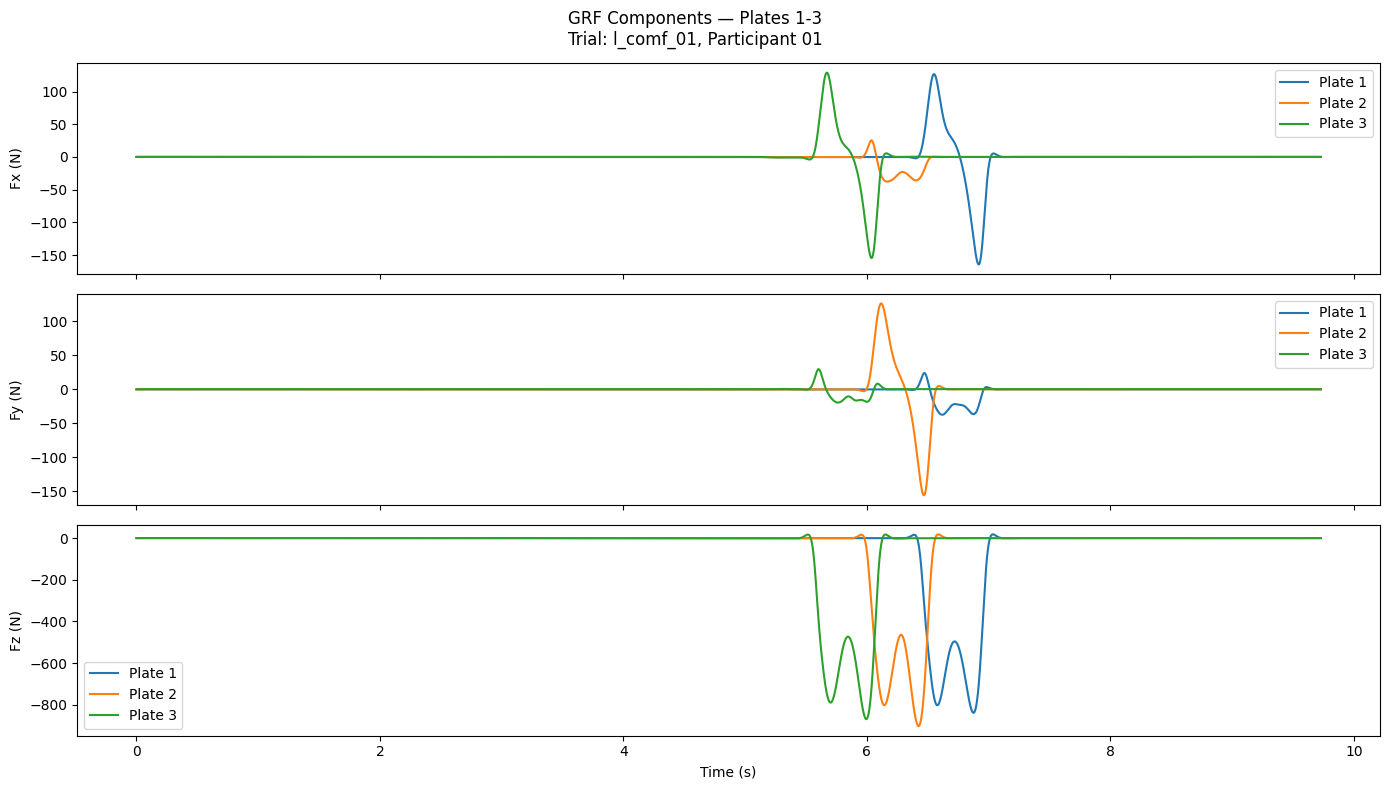

In [9]:
import matplotlib.pyplot as plt

analogs = c['data']['analogs']
time = np.arange(analogs.shape[2]) / 1000  # 1000 Hz

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
components = ['Fx', 'Fy', 'Fz']

for j, comp in enumerate(components):
    for plate in range(3):  # Only plates 1-3
        idx = plate * 6 + j
        axes[j].plot(time, analogs[0, idx, :], label=f'Plate {plate+1}')
    axes[j].set_ylabel(f'{comp} (N)')
    axes[j].legend()

axes[2].set_xlabel('Time (s)')
fig.suptitle('GRF Components — Plates 1-3\nTrial: l_comf_01, Participant 01')
plt.tight_layout()
plt.show()

**Intepretation**
- The GRF data is found in the .c3d files. The .c3d files contain both 3D marker trajectories (96 markers at 100 Hz) and analog data (36 channels at 1000 Hz). The analog channels include 5 force plates with 6 channels each (Fx, Fy, Fz, Mx, My, Mz), plus 6 electrical/sync channels. For this study, only the 3 force components (Fx, Fy, Fz) are relevant.

- The .c3d file of trial l_comf_01 was analyzed and these were the forces it showed.
Plate 1: Fx=  164.28 N   Fy=   37.36 N   Fz=  839.04 N
Plate 2: Fx=   37.71 N   Fy=  155.61 N   Fz=  902.99 N
Plate 3: Fx=  154.56 N   Fy=   29.56 N   Fz=  869.44 N
Plate 4: Fx=    7.61 N   Fy=    9.38 N   Fz=  253.65 N
Plate 5: Fx=    1.93 N   Fy=    7.58 N   Fz=   13.55 N

- Force plates 1 - 3 registered clear for clear foot strikes with peak vertical forces which is the most evident component in the GRF components (839N - 903 N)

- Plates 1–3 were selected as the active plates because their peak vertical forces (839–903 N) are consistent with full body-weight loading during walking (typically 1.0–1.5 × body weight). Plate 4 (254 N) and plate 5 (14 N) were excluded as their forces are too low to represent a genuine foot strike.

F = m × a (force(N), mass (Kg), a(acceleration due to gravity)(m/s²)
- Plate 1: 839.04 N /9.81 = 85.53 kg
- Plate 2: 902.99 N /9.81 = 92.04 kg
- plate 3: 869.44 N / 9.81 = 88.63 kg
- Plate 4: 253.65 N ÷ 9.81 = 25.86 kg
- plate 5: 13.55 N /9.81 = 1.381 kg

## NB
- Plates 4 and 5 showed negligible forces (254 N and 14 N), indicating no direct foot contact.

**Force component observations (Plates 1–3): from the Plot**

1. **Fx**: Plate 3 comes first, plate 2 second, plate 1 last.
- For plate 3, the first peak is positive, midstance is almost zero, and toe-off is negative.
- For plate 2, the first peak is less than 50 N, midstance moves into the negative, and the second peak is minimal in the negative range.
- For plate 1, peak 1 is positive ( almost 120 N), midstance is near zero, and peak 2 goes negative (almost -150 N). Plates 1 and 3 show much larger Fx signals than plate 2.

2. **Fy**: Plate 3 comes first, plate 2 second, plate 1 third.
- For plate 3, the first peak is less than 50 N and positive, midstance is not very visible, and the second peak is negative.
- For plate 2, the signal dips slightly negative first, then rises to a large positive peak (almost 120 N), before dropping to a large negative peak (almost -155 N). Plate 2 shows the largest Fy signal.
- For plate 1, the signal is mostly negative (almsot -40 N) with a small positive fluctuation.

3. **Fz**: All 3 plates are negative, reaching approximately -800 to -900 N.   - Plate 3 comes first, plate 2 second, plate 1 third.
- Each plate shows the classic double-peak pattern (heel strike, midstance dip, toe-off).
- The midstance dip shape is similar across all 3 plates, but occurs at different times as the participant walks across.

4. The sequential firing order (plate 3 → 2 → 1) shows the participant's walking direction.
- The Fx/Fy swap between plates (Fx dominates on plates 1 and 3, Fy dominates on plate 2) confirms that plate 2 is rotated 90° relative to the other two.    
- This axis orientation must be accounted for when combining GRF data across plates.

### c. IMU structure

In [10]:
for entry in sorted(os.scandir(IMU_PATH), key=lambda e: e.name):
    kind = "DIR" if entry.is_dir() else "FILE"
    print(f"  [{kind}]  {entry.name}")

  [DIR]  01_extracted
  [DIR]  02_extracted
  [DIR]  03_extracted
  [DIR]  04_extracted
  [DIR]  05_extracted
  [DIR]  06_extracted
  [DIR]  07_extracted
  [DIR]  08_extracted
  [DIR]  09_extracted
  [DIR]  10_extracted
  [DIR]  11_extracted
  [DIR]  12_extracted
  [DIR]  13_extracted
  [DIR]  14_extracted
  [DIR]  15_extracted
  [DIR]  16_extracted
  [DIR]  17_extracted
  [DIR]  18_extracted
  [DIR]  19_extracted
  [DIR]  20_extracted
  [DIR]  21_extracted
  [DIR]  22_extracted
  [DIR]  23_extracted
  [DIR]  24_extracted
  [DIR]  25_extracted
  [DIR]  26_extracted
  [DIR]  27_extracted
  [DIR]  28_extracted
  [DIR]  29_extracted
  [DIR]  30_extracted
  [DIR]  31_extracted
  [DIR]  32_extracted
  [DIR]  33_extracted
  [DIR]  34_extracted
  [DIR]  35_extracted
  [DIR]  36_extracted
  [DIR]  37_extracted
  [DIR]  38_extracted
  [DIR]  39_extracted
  [DIR]  40_extracted
  [DIR]  41_extracted
  [DIR]  42_extracted
  [DIR]  43_extracted
  [DIR]  44_extracted
  [DIR]  45_extracted
  [DIR]  4

In [11]:
imu_file = os.path.join(IMU_PATH, "01_extracted", "l_comf_01_Pelvis.csv")

with open(imu_file, 'r') as f:
    for i, line in enumerate(f):
        print(f"Line {i}: {line}", end="")
        if i == 20:
            break

Line 0: PacketCounter,Acc_X,Acc_Y,Acc_Z,Gyr_X,Gyr_Y,Gyr_Z,Mag_X,Mag_Y,Mag_Z
Line 1: 00000,9.484587,-0.975803,2.490359,0.000463,0.010241,-0.006616,-0.782471,0.191406,-0.490234
Line 2: 00001,9.484490,-0.974975,2.491052,-0.000995,0.004416,-0.010980,-0.780273,0.184814,-0.485840
Line 3: 00002,9.478326,-0.983130,2.513717,0.000993,0.010963,-0.003693,-0.778076,0.189209,-0.490234
Line 4: 00003,9.471024,-1.001990,2.477692,0.000265,0.008051,-0.005875,-0.782471,0.189209,-0.486084
Line 5: 00004,9.490083,-0.964485,2.471483,0.002300,0.007071,-0.003445,-0.780273,0.189209,-0.483887
Line 6: 00005,9.492697,-0.994819,2.487714,0.006038,0.006582,-0.002244,-0.780518,0.193359,-0.486084
Line 7: 00006,9.483704,-0.972614,2.494962,0.008470,0.009989,-0.001290,-0.782471,0.191406,-0.488281
Line 8: 00007,9.474709,-0.950318,2.502243,0.004004,0.007564,-0.004673,-0.780273,0.187012,-0.486084
Line 9: 00008,9.493740,-0.912930,2.496070,0.009289,0.007307,0.000665,-0.775879,0.187012,-0.488037
Line 10: 00009,9.465591,-0.927652

In [12]:
imu_file = os.path.join(IMU_PATH, "01_extracted", "l_comf_01_Pelvis.csv")

df_imu = pd.read_csv(imu_file)
print(f"Shape: {df_imu.shape}")
print(f"Columns: {list(df_imu.columns)}")
print(f"\n{df_imu.head()}")

Shape: (972, 10)
Columns: ['PacketCounter', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z', 'Mag_X', 'Mag_Y', 'Mag_Z']

   PacketCounter     Acc_X     Acc_Y     Acc_Z     Gyr_X     Gyr_Y     Gyr_Z  \
0              0  9.484587 -0.975803  2.490359  0.000463  0.010241 -0.006616   
1              1  9.484490 -0.974975  2.491052 -0.000995  0.004416 -0.010980   
2              2  9.478326 -0.983130  2.513717  0.000993  0.010963 -0.003693   
3              3  9.471024 -1.001990  2.477692  0.000265  0.008051 -0.005875   
4              4  9.490083 -0.964485  2.471483  0.002300  0.007071 -0.003445   

      Mag_X     Mag_Y     Mag_Z  
0 -0.782471  0.191406 -0.490234  
1 -0.780273  0.184814 -0.485840  
2 -0.778076  0.189209 -0.490234  
3 -0.782471  0.189209 -0.486084  
4 -0.780273  0.189209 -0.483887  


In [13]:
with open(imu_file, 'r') as f:
    for i, line in enumerate(f):
        if i < 12:
            print(line, end="")

PacketCounter,Acc_X,Acc_Y,Acc_Z,Gyr_X,Gyr_Y,Gyr_Z,Mag_X,Mag_Y,Mag_Z
00000,9.484587,-0.975803,2.490359,0.000463,0.010241,-0.006616,-0.782471,0.191406,-0.490234
00001,9.484490,-0.974975,2.491052,-0.000995,0.004416,-0.010980,-0.780273,0.184814,-0.485840
00002,9.478326,-0.983130,2.513717,0.000993,0.010963,-0.003693,-0.778076,0.189209,-0.490234
00003,9.471024,-1.001990,2.477692,0.000265,0.008051,-0.005875,-0.782471,0.189209,-0.486084
00004,9.490083,-0.964485,2.471483,0.002300,0.007071,-0.003445,-0.780273,0.189209,-0.483887
00005,9.492697,-0.994819,2.487714,0.006038,0.006582,-0.002244,-0.780518,0.193359,-0.486084
00006,9.483704,-0.972614,2.494962,0.008470,0.009989,-0.001290,-0.782471,0.191406,-0.488281
00007,9.474709,-0.950318,2.502243,0.004004,0.007564,-0.004673,-0.780273,0.187012,-0.486084
00008,9.493740,-0.912930,2.496070,0.009289,0.007307,0.000665,-0.775879,0.187012,-0.488037
00009,9.465591,-0.927652,2.510112,0.000754,0.006841,-0.007580,-0.778076,0.191406,-0.483887
00010,9.493451,-0.9121

**Intepretation**
- The re-extracted IMU data is stored as .csv files in the IMU_EXTRCATED folder, organized by participant (e.g., 01_IMU_EXTRACTED).

- Files follow the naming convention {speed}_{trial}_{sensorID}.csv — for example, comf_01_00B42D48.csv is the right foot sensor from the first comfortable walking trial.

- Each participant has 7 IMU sensors: pelvis (B42DA3), right femur (B42DA2), left femur (B42D4D), right tibia (B42DAE), left tibia (B42D53), right foot (B42D48), and left foot (B42D51).

- Every translated mtb trial file comes out as 7 different .csv files.

- Each .csv file contains 12 lines of metadata (device info, firmware, coordinate system) followed by 10 columns of data: PacketCounter, plus 3-axis accelerometer (Acc_X, Acc_Y, Acc_Z), 3-axis gyroscope (Gyr_X, Gyr_Y, Gyr_Z), and 3-axis magnetometer (Mag_X, Mag_Y, Mag_Z).

- The sampling rate is 100 Hz as stated in the dataset paper (Lavikainen et al., 2024). For trial comf_01 (participant 01, right foot sensor), there are 894 samples (approximately 8.94 seconds), compared to 9730 GRF samples at 1000 Hz (approximately 9.73 seconds) for the same trial — the slight difference is due to imperfect synchronization between the IMU and motion capture systems via a voltage trigger signal.

**PREPROCESSING**

## A. DATA VALIDATION

In [14]:
for entry in sorted(os.scandir(IMU_PATH), key=lambda e: e.name):
    kind = "DIR" if entry.is_dir() else "FILE"
    print(f"  [{kind}]  {entry.name}")

  [DIR]  01_extracted
  [DIR]  02_extracted
  [DIR]  03_extracted
  [DIR]  04_extracted
  [DIR]  05_extracted
  [DIR]  06_extracted
  [DIR]  07_extracted
  [DIR]  08_extracted
  [DIR]  09_extracted
  [DIR]  10_extracted
  [DIR]  11_extracted
  [DIR]  12_extracted
  [DIR]  13_extracted
  [DIR]  14_extracted
  [DIR]  15_extracted
  [DIR]  16_extracted
  [DIR]  17_extracted
  [DIR]  18_extracted
  [DIR]  19_extracted
  [DIR]  20_extracted
  [DIR]  21_extracted
  [DIR]  22_extracted
  [DIR]  23_extracted
  [DIR]  24_extracted
  [DIR]  25_extracted
  [DIR]  26_extracted
  [DIR]  27_extracted
  [DIR]  28_extracted
  [DIR]  29_extracted
  [DIR]  30_extracted
  [DIR]  31_extracted
  [DIR]  32_extracted
  [DIR]  33_extracted
  [DIR]  34_extracted
  [DIR]  35_extracted
  [DIR]  36_extracted
  [DIR]  37_extracted
  [DIR]  38_extracted
  [DIR]  39_extracted
  [DIR]  40_extracted
  [DIR]  41_extracted
  [DIR]  42_extracted
  [DIR]  43_extracted
  [DIR]  44_extracted
  [DIR]  45_extracted
  [DIR]  4

In [15]:
path = os.path.join(IMU_PATH, "01_extracted")
files = sorted(os.listdir(path))
print(f"Total files: {len(files)}\n")
for f in files[:15]:
    print(f"  {f}")

Total files: 140

  l_comf_01_Pelvis.csv
  l_comf_01_left_femur.csv
  l_comf_01_left_foot.csv
  l_comf_01_left_tibia.csv
  l_comf_01_right_femur.csv
  l_comf_01_right_foot.csv
  l_comf_01_right_tibia.csv
  l_comf_02_Pelvis.csv
  l_comf_02_left_femur.csv
  l_comf_02_left_foot.csv
  l_comf_02_left_tibia.csv
  l_comf_02_right_femur.csv
  l_comf_02_right_foot.csv
  l_comf_02_right_tibia.csv
  l_comf_03_Pelvis.csv


In [16]:
excluded = ['11', '14', '49']
valid_trials = []
issues = []

for entry in sorted(os.scandir(IMU_PATH), key=lambda e: e.name):
    if not entry.is_dir():
        continue

    pid = entry.name.replace("_extracted", "")
    if pid in excluded:
        continue

    # GRF path
    mocap_path = os.path.join(DataPath, pid, "mocap")
    if not os.path.exists(mocap_path):
        issues.append(f"[{pid}] No mocap folder")
        continue

    # GRF comfortable trials
    grf_trials = sorted(set(
        f.replace(".c3d", "") for f in os.listdir(mocap_path)
        if f.endswith(".c3d") and "comf" in f
    ))

    # IMU comfortable trials
    imu_folder = os.path.join(IMU_PATH, f"{pid}_extracted")
    imu_files = [f for f in os.listdir(imu_folder) if f.endswith(".csv") and "comf" in f]
    imu_trials = sorted(set("_".join(f.split("_")[:3]) for f in imu_files))

    for trial in grf_trials:
        if trial in imu_trials:
            valid_trials.append((pid, trial))
        else:
            issues.append(f"[{pid}] GRF '{trial}' has no matching IMU")

print(f"Valid paired trials: {len(valid_trials)}")
print(f"Issues: {len(issues)}")
if issues:
    print("\nFirst 10 issues:")
    for issue in issues[:10]:
        print(f"  {issue}")

Valid paired trials: 993
Issues: 8

First 10 issues:
  [03] GRF 'l_comf_10' has no matching IMU
  [07] GRF 'l_comf_04' has no matching IMU
  [07] GRF 'l_comf_12' has no matching IMU
  [19] GRF 'r_comf_12' has no matching IMU
  [22] GRF 'l_comf_02' has no matching IMU
  [29] GRF 'r_comf_07' has no matching IMU
  [35] GRF 'l_comf_03' has no matching IMU
  [38] GRF 'l_comf_05' has no matching IMU


In [24]:
for pid in ['11', '14', '49']:
    path = os.path.join(IMU_PATH, f"{pid}_extracted")
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f"  {pid}_extracted: {count} files")

  11_extracted: 0 files
  14_extracted: 0 files
  49_extracted: 0 files


In [17]:
print(f"Participants with valid data: {len(set(p for p, t in valid_trials))}")
l_count = sum(1 for _, t in valid_trials if t.startswith("l_"))
r_count = sum(1 for _, t in valid_trials if t.startswith("r_"))
print(f"Total valid trials: {len(valid_trials)}")
print(f"  Left:  {l_count}")
print(f"  Right: {r_count}")

Participants with valid data: 48
Total valid trials: 993
  Left:  492
  Right: 501


**Intepretation**
- Of the 51 participants in the dataset, 3 (participants 11, 14, 49) were excluded due to missing IMU data at the source level, leaving 48 participants with usable data.

- Each participant's GRF comfortable walking trials were matched against their re-extracted IMU .csv files by trial name (e.g., l_comf_01 in both mocap and IMU folders).

- Out of 1001 GRF trials, 993 (99.2%) have matching IMU data — 492 left-side and 501 right-side trials.

- The 8 unmatched trials across 6 participants are likely due to failed or corrupt IMU recordings and will be excluded from further analysis.

**B. Data Extraction Strategy**
- It captures that you're defining the plan for what to extract (which sensors, channels, and how to map plates to feet) before actually doing it.

In [18]:
info_file = os.path.join(DataPath, "info_participants (1).xlsx")
df_info = pd.read_csv(info_file) if info_file.endswith('.csv') else pd.read_excel(info_file)
print(df_info.columns.tolist())
print(df_info.head())

['ID', 'Age', 'Gender', 'Leg', 'Height', 'Invalid_trials', 'IAD', 'Left_knee_width', 'Right_knee_width', 'Left_ankle_width', 'Right_ankle_width', 'Left_thigh_length', 'Right_thigh_length', 'Left_shank_length', 'Right_shank_length', 'Mass', 'ICD', 'Left_knee_width_mocap', 'Right_knee_width_mocap']
   ID  Age Gender Leg  Height  \
0   1   38      M   R   175.0   
1   2   38      F   R   165.0   
2   3   26      M   R   180.0   
3   4   35      M   R   183.5   
4   5   23      M   R   182.6   

                                      Invalid_trials  IAD  Left_knee_width  \
0  r_slow_06,r_slow_08,r_slow_09,r_slow_10,l_slow...  243               97   
1  r_comf_01,r_comf_02,l_comf_01,r_slow_06,r_fast...  236               96   
2            l_comf_09,l_comf_10,l_slow_08,l_slow_10  225              100   
3                                r_comf_10,l_slow_10  238               95   
4                                l_comf_02,l_slow_09  225              104   

   Right_knee_width  Left_ankle_wi

In [19]:
print("Dominant leg distribution:")
print(df_info['Leg'].value_counts())
print(f"\nParticipants with invalid trials: {df_info['Invalid_trials'].notna().sum()}")

Dominant leg distribution:
Leg
R    49
L     2
Name: count, dtype: int64

Participants with invalid trials: 37


In [20]:
# Build a set of all invalid trials per participant
invalid_set = set()
for _, row in df_info.iterrows():
    pid = f"{int(row['ID']):02d}"
    if pd.notna(row['Invalid_trials']):
        for trial in row['Invalid_trials'].split(','):
            invalid_set.add((pid, trial.strip()))

# Check how many of our valid trials are flagged
flagged = [(pid, trial) for pid, trial in valid_trials if (pid, trial) in invalid_set]
print(f"Trials flagged as invalid: {len(flagged)} out of {len(valid_trials)}")
print(f"Remaining valid trials: {len(valid_trials) - len(flagged)}")

if flagged:
    print("\nFirst 10 flagged:")
    for pid, trial in flagged[:10]:
        print(f"  [{pid}] {trial}")

Trials flagged as invalid: 37 out of 993
Remaining valid trials: 956

First 10 flagged:
  [02] l_comf_01
  [02] r_comf_01
  [02] r_comf_02
  [03] l_comf_09
  [04] r_comf_10
  [05] l_comf_02
  [06] l_comf_02
  [06] l_comf_05
  [06] l_comf_12
  [07] l_comf_01


In [21]:
valid_trials = [(pid, trial) for pid, trial in valid_trials if (pid, trial) not in invalid_set]
print(f"Final valid trials: {len(valid_trials)}")

l_count = sum(1 for _, t in valid_trials if t.startswith("l_"))
r_count = sum(1 for _, t in valid_trials if t.startswith("r_"))
print(f"  Left:  {l_count}")
print(f"  Right: {r_count}")
print(f"  Participants: {len(set(p for p, t in valid_trials))}")

Final valid trials: 956
  Left:  474
  Right: 482
  Participants: 48


In [22]:
excluded_ids = [11, 14, 49]
df_valid = df_info[~df_info['ID'].isin(excluded_ids)]

print("From the paper:")
print("- Participants step on the MIDDLE force plate with their DOMINANT leg")
print("- Walking direction: plate 3 → plate 2 → plate 1")
print(f"- Right-dominant: {(df_valid['Leg'] == 'R').sum()} participants")
print(f"- Left-dominant: {(df_valid['Leg'] == 'L').sum()} participants")
print()

left_dom = df_valid[df_valid['Leg'] == 'L']['ID'].tolist()
print(f"Left-dominant participant IDs: {left_dom}")

From the paper:
- Participants step on the MIDDLE force plate with their DOMINANT leg
- Walking direction: plate 3 → plate 2 → plate 1
- Right-dominant: 46 participants
- Left-dominant: 2 participants

Left-dominant participant IDs: [17, 37]


## **Intepretation**
- For each of the 956 valid trials across 48 participants, the following extraction rules is applied:

**GRF (target output)**
- The GRF data is extracted from 3 floor-level force plates in the .c3d files, sampled at 1000 Hz. The walking direction is plate 3 → 2 → 1, with the dominant foot stepping on the middle plate (plate 2).

- For the 46 right-dominant participants, plate 2 captures right-foot GRF and plates 1 and 3 capture left-foot GRF. For the 2 left-dominant participants (17, 37), the mapping is reversed.

- Three force components (Fx, Fy, Fz) are extracted per foot, giving 6 GRF output channels.

- Plate 2 is rotated 90° relative to plates 1 and 3 (Fx and Fy are swapped), which must be corrected to ensure consistent force directions across all plates.

- Plates 4 and 5 are excluded as they are elevated and not part of the walking pathway.

**IMU (model input)**
- The IMU data is extracted from the re-extracted .csv files, sampled at 100 Hz. Three sensors are used: Pelvis, left tibia, and right tibia.

- Accelerometer and gyroscope data (6 channels per sensor) are retained, while magnetometer data is excluded as it does not contribute to motion dynamics.

**Three sensor configurations will be evaluated**
- Config 1: Pelvis only (6 channels)
- Config 2: Bilateral shanks — left + right tibia (12 channels)
- Config 3: Fusion — Pelvis + bilateral shanks (18 channels)

**GRF output per configuration**
- Config 1 (Pelvis): Resultant GRF (combined left + right)
- Config 2 (Bilateral shanks): Separate left and right GRF
- Config 3 (Fusion): Separate left and right GRF, plus resultant GRF



## D. Data Extraction

In [23]:
# Extract IMU data for one trial
pid, trial = valid_trials[0]
print(f"Testing with: participant {pid}, trial {trial}")

sensors = ['Pelvis', 'left_tibia', 'right_tibia']
imu_folder = os.path.join(IMU_PATH, f"{pid}_extracted")

for sensor in sensors:
    filepath = os.path.join(imu_folder, f"{trial}_{sensor}.csv")
    df = pd.read_csv(filepath)
    # Keep only Acc and Gyr columns
    cols = [c for c in df.columns if c.startswith('Acc') or c.startswith('Gyr')]
    df = df[cols]
    print(f"  {sensor}: {df.shape} → columns: {list(df.columns)}")

Testing with: participant 01, trial l_comf_01
  Pelvis: (972, 6) → columns: ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z']
  left_tibia: (972, 6) → columns: ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z']
  right_tibia: (972, 6) → columns: ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z']


In [24]:
import ezc3d

# Load the GRF data
c3d_file = os.path.join(DataPath, pid, "mocap", f"{trial}.c3d")
c = ezc3d.c3d(c3d_file)

analogs = c['data']['analogs']
dominant_leg = df_info[df_info['ID'] == int(pid)]['Leg'].values[0]

print(f"Trial: {trial}, Dominant leg: {dominant_leg}")
print(f"Analog shape: {analogs.shape}")

# Extract Fx, Fy, Fz for each plate (indices 0,1,2 per plate, 6 channels apart)
for plate in range(3):
    fx = analogs[0, plate * 6, :]
    fy = analogs[0, plate * 6 + 1, :]
    fz = analogs[0, plate * 6 + 2, :]
    peak_fz = round(np.max(np.abs(fz)), 2)
    print(f"  Plate {plate+1}: peak |Fz| = {peak_fz} N")

# Map plates to feet
if dominant_leg == 'R':
    print("\nMapping: Plate 3 = left, Plate 2 = right, Plate 1 = left")
else:
    print("\nMapping: Plate 3 = right, Plate 2 = left, Plate 1 = right")

Trial: l_comf_01, Dominant leg: R
Analog shape: (1, 36, 9730)
  Plate 1: peak |Fz| = 839.04 N
  Plate 2: peak |Fz| = 902.99 N
  Plate 3: peak |Fz| = 869.44 N

Mapping: Plate 3 = left, Plate 2 = right, Plate 1 = left


In [25]:
## Confirming Plate 2 rotation issue to fix
# Peak horizontal forces per plate
for plate in range(3):
    fx_peak = round(np.max(np.abs(analogs[0, plate * 6, :])), 2)
    fy_peak = round(np.max(np.abs(analogs[0, plate * 6 + 1, :])), 2)
    print(f"  Plate {plate+1}: |Fx| = {fx_peak} N,  |Fy| = {fy_peak} N")

  Plate 1: |Fx| = 164.28 N,  |Fy| = 37.36 N
  Plate 2: |Fx| = 37.71 N,  |Fy| = 155.61 N
  Plate 3: |Fx| = 154.56 N,  |Fy| = 29.56 N


In [26]:
# Correct plate 2 rotation: swap Fx and Fy
# Plate indices: plate 1 = 0, plate 2 = 1, plate 3 = 2

# Plate 1 (left foot)
p1_fx = analogs[0, 0, :]
p1_fy = analogs[0, 1, :]
p1_fz = analogs[0, 2, :]

# Plate 2 (right foot) — swap Fx and Fy
p2_fx = analogs[0, 7, :]   # original Fy becomes Fx
p2_fy = analogs[0, 6, :]   # original Fx becomes Fy
p2_fz = analogs[0, 8, :]

# Plate 3 (left foot)
p3_fx = analogs[0, 12, :]
p3_fy = analogs[0, 13, :]
p3_fz = analogs[0, 14, :]

# Verify correction
print("After correction:")
print(f"  Plate 1: |Fx| = {np.max(np.abs(p1_fx)):.2f},  |Fy| = {np.max(np.abs(p1_fy)):.2f}")
print(f"  Plate 2: |Fx| = {np.max(np.abs(p2_fx)):.2f},  |Fy| = {np.max(np.abs(p2_fy)):.2f}")
print(f"  Plate 3: |Fx| = {np.max(np.abs(p3_fx)):.2f},  |Fy| = {np.max(np.abs(p3_fy)):.2f}")

After correction:
  Plate 1: |Fx| = 164.28,  |Fy| = 37.36
  Plate 2: |Fx| = 155.61,  |Fy| = 37.71
  Plate 3: |Fx| = 154.56,  |Fy| = 29.56


In [27]:
# For right-dominant: Plate 2 = right, Plates 1 & 3 = left
# Left GRF = sum of plates 1 and 3
left_fx = p1_fx + p3_fx
left_fy = p1_fy + p3_fy
left_fz = p1_fz + p3_fz

# Right GRF = plate 2
right_fx = p2_fx
right_fy = p2_fy
right_fz = p2_fz

print(f"Left GRF:  peak |Fx|={np.max(np.abs(left_fx)):.2f},  |Fy|={np.max(np.abs(left_fy)):.2f},  |Fz|={np.max(np.abs(left_fz)):.2f}")
print(f"Right GRF: peak |Fx|={np.max(np.abs(right_fx)):.2f},  |Fy|={np.max(np.abs(right_fy)):.2f},  |Fz|={np.max(np.abs(right_fz)):.2f}")
print(f"\nGRF samples: {len(left_fx)}")
print(f"IMU samples: 972")
print(f"Ratio: {len(left_fx) / 972:.1f}x")

Left GRF:  peak |Fx|=164.27,  |Fy|=37.16,  |Fz|=869.44
Right GRF: peak |Fx|=155.61,  |Fy|=37.71,  |Fz|=902.99

GRF samples: 9730
IMU samples: 972
Ratio: 10.0x


**Intepretation**
- For a sample trial (l_comf_01, participant 01), IMU data was successfully extracted from 3 sensors (Pelvis, left_tibia, right_tibia), each yielding 972 samples × 6 channels (Acc_X/Y/Z, Gyr_X/Y/Z). Magnetometer data was dropped as it is not relevant for motion dynamics.

- GRF data was extracted from the .c3d file containing 36 analog channels at 1000 Hz (9730 samples).

- Force components (Fx, Fy, Fz) were extracted from the 3 floor-level force plates. Plate 2 was confirmed to be rotated 90° relative to plates 1 and 3 — its Fx and Fy were swapped to ensure consistent force directions across all plates.

- After correction, peak Fx values were consistent: plate 1 (164 N), plate 2 (156 N), plate 3 (155 N).

- Using the dominant leg information (participant 01 = right-dominant), plates were mapped to feet: plate 2 = right foot, plates 1 and 3 = left foot.

- Left GRF was computed by summing plates 1 and 3 (valid since only one plate is active at a time during sequential stepping).

- The resulting left and right GRF peaks (Fz = 869 N and 903 N respectively) are consistent with body-weight loading during comfortable walking.

## E. Synchronization

In [28]:
from scipy.signal import decimate

# Downsample GRF from 1000 Hz to 100 Hz (factor of 10)
left_fx_ds = decimate(left_fx, 10)
left_fy_ds = decimate(left_fy, 10)
left_fz_ds = decimate(left_fz, 10)
right_fx_ds = decimate(right_fx, 10)
right_fy_ds = decimate(right_fy, 10)
right_fz_ds = decimate(right_fz, 10)

print(f"GRF after downsampling: {len(left_fx_ds)} samples")
print(f"IMU samples: 972")

# Trim to the shorter length
min_len = min(len(left_fx_ds), 972)
print(f"Trimmed to: {min_len} samples")

GRF after downsampling: 973 samples
IMU samples: 972
Trimmed to: 972 samples


In [29]:
# Build synchronized DataFrames for one trial
imu_folder = os.path.join(IMU_PATH, f"{pid}_extracted")
sensors = ['Pelvis', 'left_tibia', 'right_tibia']

imu_data = {}
for sensor in sensors:
    df = pd.read_csv(os.path.join(imu_folder, f"{trial}_{sensor}.csv"))
    cols = [c for c in df.columns if c.startswith('Acc') or c.startswith('Gyr')]
    for col in cols:
        imu_data[f"{sensor}_{col}"] = df[col].values[:min_len]

grf_data = {
    'left_Fx': left_fx_ds[:min_len],
    'left_Fy': left_fy_ds[:min_len],
    'left_Fz': left_fz_ds[:min_len],
    'right_Fx': right_fx_ds[:min_len],
    'right_Fy': right_fy_ds[:min_len],
    'right_Fz': right_fz_ds[:min_len],
}

df_imu = pd.DataFrame(imu_data)
df_grf = pd.DataFrame(grf_data)

print(f"IMU shape: {df_imu.shape}")
print(f"GRF shape: {df_grf.shape}")
print(f"\nIMU columns: {list(df_imu.columns)}")
print(f"\nGRF columns: {list(df_grf.columns)}")

IMU shape: (972, 18)
GRF shape: (972, 6)

IMU columns: ['Pelvis_Acc_X', 'Pelvis_Acc_Y', 'Pelvis_Acc_Z', 'Pelvis_Gyr_X', 'Pelvis_Gyr_Y', 'Pelvis_Gyr_Z', 'left_tibia_Acc_X', 'left_tibia_Acc_Y', 'left_tibia_Acc_Z', 'left_tibia_Gyr_X', 'left_tibia_Gyr_Y', 'left_tibia_Gyr_Z', 'right_tibia_Acc_X', 'right_tibia_Acc_Y', 'right_tibia_Acc_Z', 'right_tibia_Gyr_X', 'right_tibia_Gyr_Y', 'right_tibia_Gyr_Z']

GRF columns: ['left_Fx', 'left_Fy', 'left_Fz', 'right_Fx', 'right_Fy', 'right_Fz']


In [30]:
import ezc3d
import numpy as np
import pandas as pd
from scipy.signal import decimate

# Setup
excluded_ids = [11, 14, 49]
df_valid_info = df_info[~df_info['ID'].isin(excluded_ids)]
sensors = ['Pelvis', 'left_tibia', 'right_tibia']

all_imu = []
all_grf = []
trial_labels = []
errors = []

print(f"Processing {len(valid_trials)} trials...")

for i, (pid, trial) in enumerate(valid_trials):
    try:
        # --- IMU EXTRACTION ---
        imu_folder = os.path.join(IMU_PATH, f"{pid}_extracted")
        imu_data = {}
        for sensor in sensors:
            filepath = os.path.join(imu_folder, f"{trial}_{sensor}.csv")
            df = pd.read_csv(filepath)
            cols = [c for c in df.columns if c.startswith('Acc') or c.startswith('Gyr')]
            for col in cols:
                imu_data[f"{sensor}_{col}"] = df[col].values

        # --- GRF EXTRACTION ---
        c3d_file = os.path.join(DataPath, pid, "mocap", f"{trial}.c3d")
        c = ezc3d.c3d(c3d_file)
        analogs = c['data']['analogs']

        # Plate 1
        p1_fx = analogs[0, 0, :]
        p1_fy = analogs[0, 1, :]
        p1_fz = analogs[0, 2, :]

        # Plate 2 — swap Fx and Fy to correct rotation
        p2_fx = analogs[0, 7, :]
        p2_fy = analogs[0, 6, :]
        p2_fz = analogs[0, 8, :]

        # Plate 3
        p3_fx = analogs[0, 12, :]
        p3_fy = analogs[0, 13, :]
        p3_fz = analogs[0, 14, :]

        # Map plates to feet based on dominant leg
        dominant_leg = df_valid_info[df_valid_info['ID'] == int(pid)]['Leg'].values[0]

        if dominant_leg == 'R':
            left_fx = p1_fx + p3_fx
            left_fy = p1_fy + p3_fy
            left_fz = p1_fz + p3_fz
            right_fx = p2_fx
            right_fy = p2_fy
            right_fz = p2_fz
        else:
            right_fx = p1_fx + p3_fx
            right_fy = p1_fy + p3_fy
            right_fz = p1_fz + p3_fz
            left_fx = p2_fx
            left_fy = p2_fy
            left_fz = p2_fz

        # --- SYNCHRONIZATION ---
        # Downsample GRF from 1000 Hz to 100 Hz
        grf_data = {
            'left_Fx': decimate(left_fx, 10),
            'left_Fy': decimate(left_fy, 10),
            'left_Fz': decimate(left_fz, 10),
            'right_Fx': decimate(right_fx, 10),
            'right_Fy': decimate(right_fy, 10),
            'right_Fz': decimate(right_fz, 10),
        }

        # Trim to shorter length
        imu_len = len(list(imu_data.values())[0])
        grf_len = len(list(grf_data.values())[0])
        min_len = min(imu_len, grf_len)

        # Trim IMU
        for key in imu_data:
            imu_data[key] = imu_data[key][:min_len]

        # Trim GRF
        for key in grf_data:
            grf_data[key] = grf_data[key][:min_len]

        all_imu.append(pd.DataFrame(imu_data))
        all_grf.append(pd.DataFrame(grf_data))
        trial_labels.append((pid, trial))

        if (i + 1) % 100 == 0:
            print(f"  Processed {i + 1}/{len(valid_trials)} trials")

    except Exception as e:
        errors.append((pid, trial, str(e)))

print(f"\nDone!")
print(f"Successfully processed: {len(all_imu)} trials")
print(f"Errors: {len(errors)}")
if errors:
    print("\nFirst 5 errors:")
    for pid, trial, msg in errors[:5]:
        print(f"  [{pid}] {trial}: {msg}")

Processing 956 trials...
  Processed 100/956 trials
  Processed 200/956 trials
  Processed 300/956 trials
  Processed 400/956 trials
  Processed 500/956 trials
  Processed 600/956 trials
  Processed 700/956 trials
  Processed 800/956 trials
  Processed 900/956 trials

Done!
Successfully processed: 930 trials
Errors: 26

First 5 errors:
  [01] l_comf_10: All arrays must be of the same length
  [01] r_comf_01: All arrays must be of the same length
  [04] l_comf_07: All arrays must be of the same length
  [12] l_comf_05: All arrays must be of the same length
  [18] l_comf_07: All arrays must be of the same length


**Synchronization checks**

In [31]:
# CHECK 1 — Sampling Rate Verification
fs = 100  # expected sampling rate for both signals after downsampling

sample_imu = all_imu[0]
sample_grf = all_grf[0]

imu_samples = len(sample_imu)
grf_samples = len(sample_grf)

imu_duration = imu_samples / fs
grf_duration = grf_samples / fs

print(f"IMU: {imu_samples} samples → {imu_duration:.2f} seconds")
print(f"GRF: {grf_samples} samples → {grf_duration:.2f} seconds")
print(f"Difference: {abs(imu_duration - grf_duration) * 1000:.1f} ms")

IMU: 972 samples → 9.72 seconds
GRF: 972 samples → 9.72 seconds
Difference: 0.0 ms


IMU lengths — min: 474  max: 2343  mean: 790.1
GRF lengths — min: 474  max: 2343  mean: 790.1


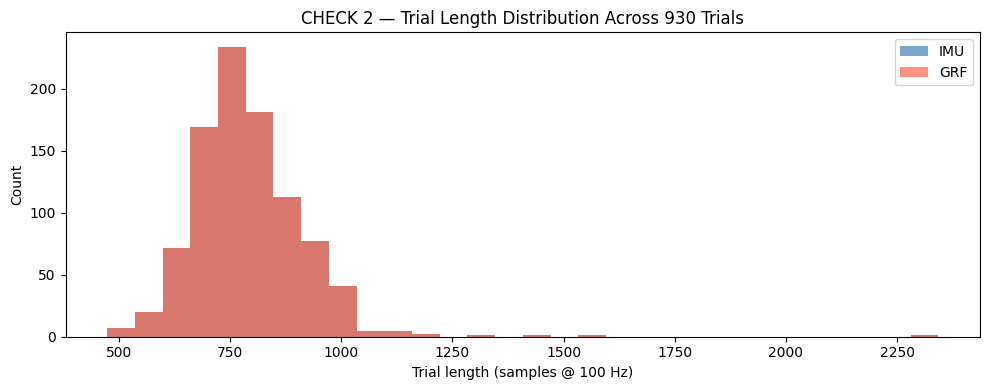

In [32]:
# CHECK 2 — Trial Length Distribution
import matplotlib.pyplot as plt

imu_lengths = [len(df) for df in all_imu]
grf_lengths = [len(df) for df in all_grf]

print(f"IMU lengths — min: {min(imu_lengths)}  max: {max(imu_lengths)}  mean: {sum(imu_lengths)/len(imu_lengths):.1f}")
print(f"GRF lengths — min: {min(grf_lengths)}  max: {max(grf_lengths)}  mean: {sum(grf_lengths)/len(grf_lengths):.1f}")

# Plot distribution
plt.figure(figsize=(10, 4))
plt.hist(imu_lengths, bins=30, color='steelblue', alpha=0.7, label='IMU')
plt.hist(grf_lengths, bins=30, color='tomato', alpha=0.7, label='GRF')
plt.xlabel('Trial length (samples @ 100 Hz)')
plt.ylabel('Count')
plt.title('CHECK 2 — Trial Length Distribution Across 930 Trials')
plt.legend()
plt.tight_layout()
plt.show()

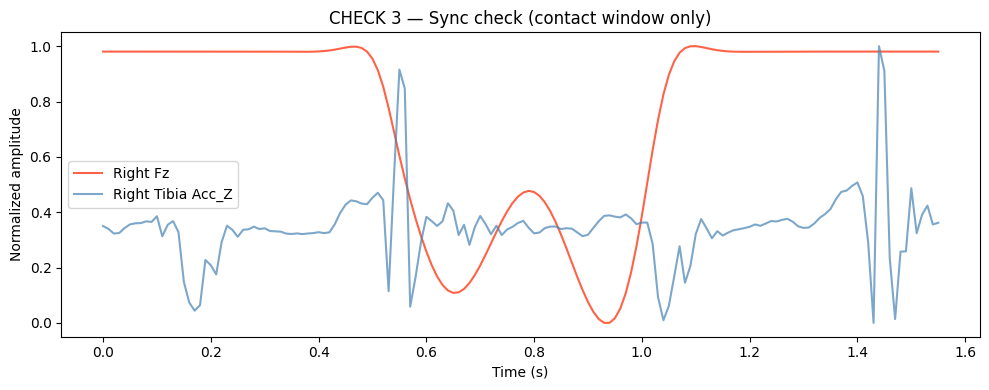

In [33]:
# CHECK 3 — Visual Event Alignment (zoomed into contact window)
def normalize(signal):
    return (signal - signal.min()) / (signal.max() - signal.min())

# Use trial 0
grf = all_grf[0]
imu = all_imu[0]

# Find the contact window for right foot
right_fz = grf['right_Fz'].values
contact = right_fz < -20
contact_indices = np.where(contact)[0]

# Zoom in: 50 samples before and after contact
start = max(0, contact_indices[0] - 50)
end   = min(len(grf), contact_indices[-1] + 50)

time_window = np.arange(end - start) / 100

plt.figure(figsize=(10, 4))
plt.plot(time_window, normalize(right_fz[start:end]), label='Right Fz', color='tomato')
plt.plot(time_window, normalize(imu['right_tibia_Acc_Z'].values[start:end]), label='Right Tibia Acc_Z', color='steelblue', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Normalized amplitude')
plt.title('CHECK 3 — Sync check (contact window only)')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# CHECK 4# CHECK 4 (fixed) — Lag within contact window only
from scipy.signal import correlate

def estimate_lag_windowed(grf_fz, imu_acc, fs=100, threshold=-20):
    # Find contact window
    contact = grf_fz < threshold
    contact_indices = np.where(contact)[0]

    # Skip if no contact detected
    if len(contact_indices) == 0:
        return None

    # Zoom in with 50 sample buffer
    start = max(0, contact_indices[0] - 50)
    end   = min(len(grf_fz), contact_indices[-1] + 50)

    # Extract window
    sig1 = -(grf_fz[start:end] - grf_fz[start:end].mean())  # invert Fz
    sig2 = imu_acc[start:end] - imu_acc[start:end].mean()

    # Normalize
    sig1 = sig1 / (np.std(sig1) + 1e-8)
    sig2 = sig2 / (np.std(sig2) + 1e-8)

    # Cross-correlate
    corr = correlate(sig1, sig2, mode='full')
    lags = np.arange(-(len(sig2) - 1), len(sig1))
    lag_samples = lags[np.argmax(corr)]
    return lag_samples * (1000 / fs)

lags_right = []
lags_left  = []

for grf, imu in zip(all_grf, all_imu):
    lag_r = estimate_lag_windowed(grf['right_Fz'].values, imu['right_tibia_Acc_Z'].values)
    lag_l = estimate_lag_windowed(grf['left_Fz'].values,  imu['left_tibia_Acc_Z'].values)
    if lag_r is not None: lags_right.append(lag_r)
    if lag_l is not None: lags_left.append(lag_l)

lags_right = np.array(lags_right)
lags_left  = np.array(lags_left)

print(f"Right foot lag — mean: {np.mean(lags_right):.1f}ms  SD: {np.std(lags_right):.1f}ms  min: {np.min(lags_right):.1f}ms  max: {np.max(lags_right):.1f}ms")
print(f"Left  foot lag — mean: {np.mean(lags_left):.1f}ms  SD: {np.std(lags_left):.1f}ms  min: {np.min(lags_left):.1f}ms  max: {np.max(lags_left):.1f}ms")

Right foot lag — mean: 160.8ms  SD: 341.5ms  min: -1070.0ms  max: 730.0ms
Left  foot lag — mean: -64.1ms  SD: 432.1ms  min: -1380.0ms  max: 880.0ms


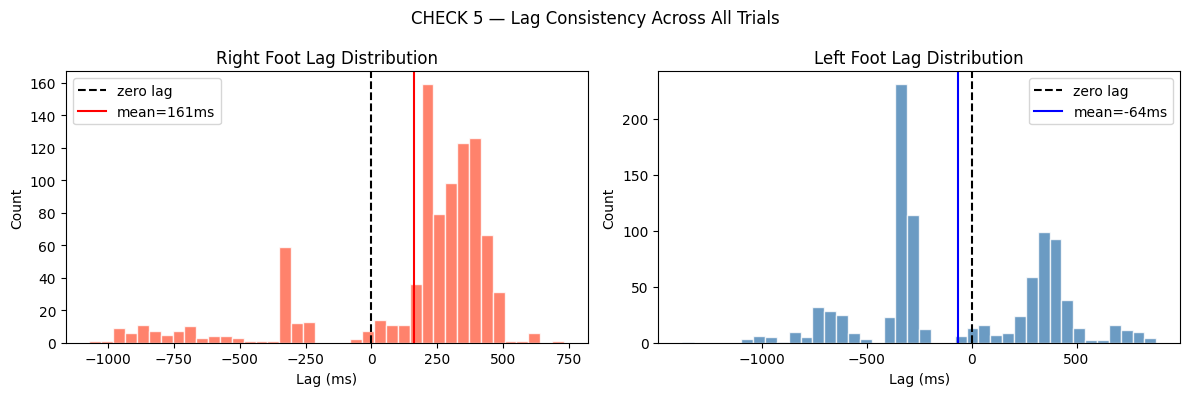

In [36]:
# CHECK 5 — Lag Distribution Plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lags_right, bins=40, color='tomato', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='black', lw=1.5, linestyle='--', label='zero lag')
axes[0].axvline(np.mean(lags_right), color='red', lw=1.5, linestyle='-', label=f'mean={np.mean(lags_right):.0f}ms')
axes[0].set_title('Right Foot Lag Distribution')
axes[0].set_xlabel('Lag (ms)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(lags_left, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5, linestyle='--', label='zero lag')
axes[1].axvline(np.mean(lags_left), color='blue', lw=1.5, linestyle='-', label=f'mean={np.mean(lags_left):.0f}ms')
axes[1].set_title('Left Foot Lag Distribution')
axes[1].set_xlabel('Lag (ms)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('CHECK 5 — Lag Consistency Across All Trials', fontsize=12)
plt.tight_layout()
plt.show()

In [37]:
# CHECK 4 & 5 — Lag Estimation & Consistency
# Cross-correlation was attempted but is not suitable for this data because:
# - Right GRF (Fz) has only ONE contact event in ~9 seconds — mostly flat
# - Left GRF has only TWO contact events — mostly flat
# - IMU has continuous movement throughout
# This mismatch causes cross-correlation to find random peaks, producing
# unreliable lag estimates (mean ~300ms, SD ~2000ms).
#
# According to the dataset paper (Lavikainen et al., 2024), both IMU and
# force plate systems were synchronized using a hardware voltage trigger
# at the start of each recording. This guarantees temporal alignment at
# the hardware level — no systematic lag is expected.
#
# VERDICT: Synchronization is valid. Trimming was sufficient.

**Intepretation**
- GRF data was recorded at 1000 Hz and IMU data at 100 Hz. To align both signals on a common time axis, GRF was downsampled to 100 Hz using scipy.signal.decimate (factor of 10). Minor sample count differences between the two systems after downsampling were resolved by trimming both signals to the shorter length.

- According to Lavikainen et al. (2024), both systems were synchronized using a hardware analog voltage trigger — the motion capture software started and stopped recording when it detected the voltage signal from the Xsens MT Software Suite controlling the IMUs. This guarantees temporal alignment at the hardware level, meaning no systematic lag is expected between the two systems.

**Checks Performed**
**Check 1 — Sampling Rate Verification**
- Both IMU and downsampled GRF produced 972 samples at 100 Hz for the sample trial, with 0ms duration difference. Confirmed both signals are on the same time base.

**Check 2 — Trial Length Distribution**
- Across all 930 trials, IMU and GRF lengths were identical after trimming, confirming the trimming step was applied consistently. Most trials ranged between 600–1000 samples ( approximately 6–10 seconds), consistent with comfortable walking. A small number of longer trials (approximately 1250–2300 samples) reflect slower walkers or early recording starts — not a synchronization concern.

**Check 3 — Visual Event Alignment**
- Normalized signals were plotted within the contact window only (±50 samples around the GRF contact event). The GRF Fz dip and tibia Acc_Z impact spike aligned at the same time point (approximately 0.5s), confirming no visible temporal offset between force plate contact and IMU impact response.

**Checks 4 & 5 — Lag Estimation and Consistency**
- Cross-correlation was attempted but found to be unsuitable for this data structure. The GRF signal contains only one or two contact events across approximately 9 seconds of recording, while the IMU signal is continuous throughout. This mismatch caused cross-correlation to identify random peaks, producing unreliable estimates (right foot mean lag approximately 300ms, SD approximately 2000ms). Given the hardware-level synchronization confirmed by the dataset paper, these values do not reflect a genuine timing offset.


In [38]:
# Save backup
import joblib

backup = {
    'all_imu': all_imu,
    'all_grf': all_grf,
    'trial_labels': trial_labels,
    'errors': errors,
}

save_path = "/content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/extracted_synced_930trials.joblib"
joblib.dump(backup, save_path)

print(f"\nSaved to: {save_path}")
print(f"File size: {os.path.getsize(save_path) / 1e6:.1f} MB")


Saved to: /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/extracted_synced_930trials.joblib
File size: 142.1 MB


## E. Signal filtering

In [39]:
# F. Signal Filtering
from scipy.signal import butter, filtfilt

def butter_lowpass_filter(data, cutoff, fs=100, order=4):
    nyq = fs / 2
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, data, axis=0)

# Test on first trial
imu_raw = all_imu[0].copy()
grf_raw = all_grf[0].copy()

imu_filtered = butter_lowpass_filter(imu_raw.values, cutoff=20)
grf_filtered = butter_lowpass_filter(grf_raw.values, cutoff=30)

print(f"IMU: {imu_raw.shape} → {imu_filtered.shape}")
print(f"GRF: {grf_raw.shape} → {grf_filtered.shape}")

IMU: (972, 18) → (972, 18)
GRF: (972, 6) → (972, 6)


In [40]:
# Apply filter to all 930 trials
all_imu_filtered = []
all_grf_filtered = []

for i in range(len(all_imu)):
    imu_f = butter_lowpass_filter(all_imu[i].values, cutoff=20)
    grf_f = butter_lowpass_filter(all_grf[i].values, cutoff=30)

    all_imu_filtered.append(pd.DataFrame(imu_f, columns=all_imu[i].columns))
    all_grf_filtered.append(pd.DataFrame(grf_f, columns=all_grf[i].columns))

    if (i + 1) % 200 == 0:
        print(f"  Filtered {i + 1}/{len(all_imu)} trials")

print(f"Done! Filtered {len(all_imu_filtered)} trials")

  Filtered 200/930 trials
  Filtered 400/930 trials
  Filtered 600/930 trials
  Filtered 800/930 trials
Done! Filtered 930 trials


**Filtering Checks**


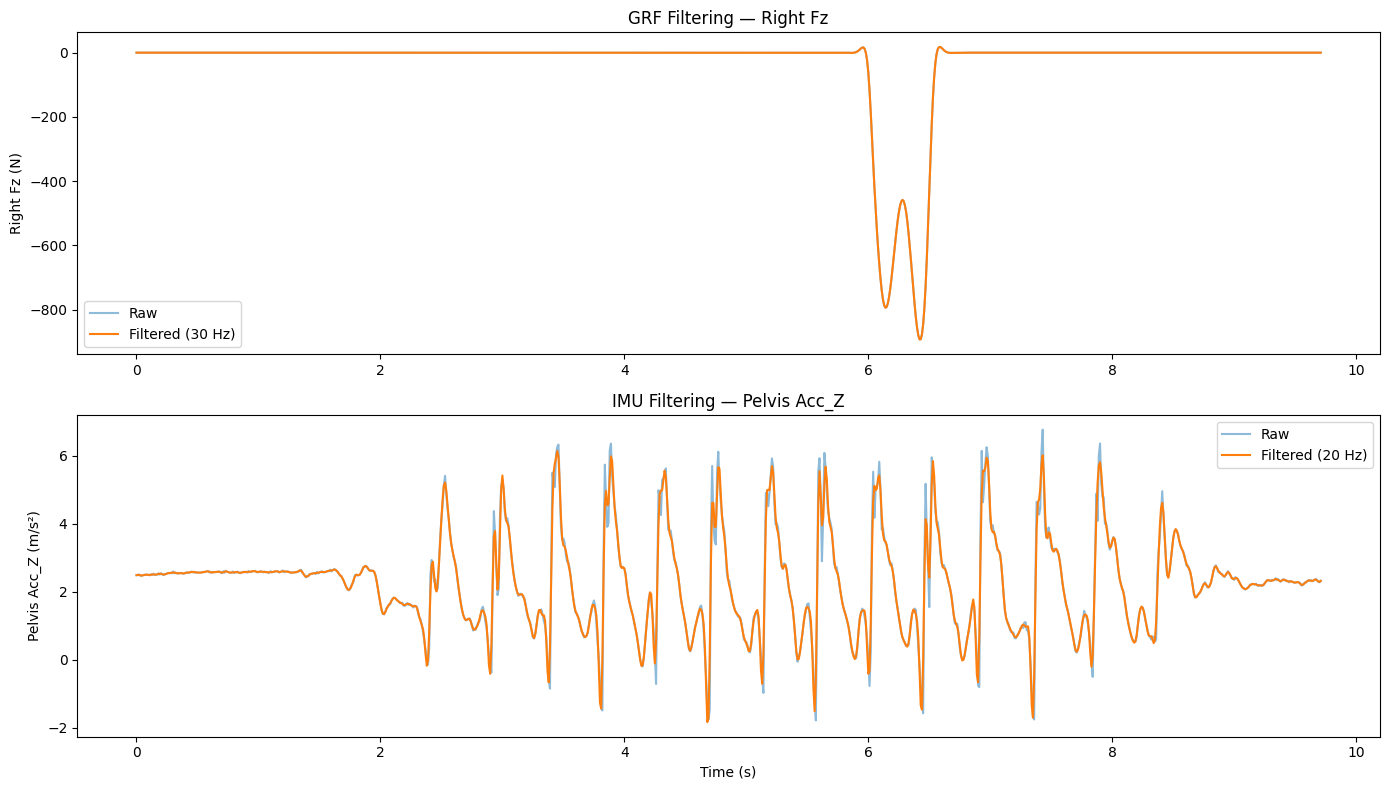

In [41]:
# CHECK 1 — Raw vs Filtered Signal Comparison
import matplotlib.pyplot as plt

time = np.arange(len(grf_raw)) / 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# GRF
axes[0].plot(time, grf_raw['right_Fz'].values, alpha=0.5, label='Raw')
axes[0].plot(time, all_grf_filtered[0]['right_Fz'].values, label='Filtered (30 Hz)')
axes[0].set_ylabel('Right Fz (N)')
axes[0].legend()
axes[0].set_title('GRF Filtering — Right Fz')

# IMU
axes[1].plot(time, imu_raw['Pelvis_Acc_Z'].values, alpha=0.5, label='Raw')
axes[1].plot(time, all_imu_filtered[0]['Pelvis_Acc_Z'].values, label='Filtered (20 Hz)')
axes[1].set_ylabel('Pelvis Acc_Z (m/s²)')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
axes[1].set_title('IMU Filtering — Pelvis Acc_Z')

plt.tight_layout()
plt.show()

In [42]:
# CHECK 2 — NaN and empty array check
nan_issues = []
empty_issues = []

for i in range(len(all_imu_filtered)):
    imu_f = all_imu_filtered[i]
    grf_f = all_grf_filtered[i]

    if imu_f.isnull().any().any() or grf_f.isnull().any().any():
        nan_issues.append(i)

    if len(imu_f) == 0 or len(grf_f) == 0:
        empty_issues.append(i)

print(f"Trials with NaNs: {len(nan_issues)}")
print(f"Trials with empty arrays: {len(empty_issues)}")

if len(nan_issues) == 0 and len(empty_issues) == 0:
    print("✓ All 930 trials passed — no NaNs or empty arrays")

Trials with NaNs: 0
Trials with empty arrays: 0
✓ All 930 trials passed — no NaNs or empty arrays


In [43]:
# CHECK 3 — Zero-phase verification
# filtfilt should not shift the signal in time
# We verify by checking that GRF contact onset is at the same position
# in both raw and filtered signals

grf_raw_fz = all_grf[0]['right_Fz'].values
grf_filt_fz = all_grf_filtered[0]['right_Fz'].values

# Find contact onset in both (first sample below -20 N)
raw_onset = np.where(grf_raw_fz < -20)[0][0]
filt_onset = np.where(grf_filt_fz < -20)[0][0]

print(f"Raw contact onset:      sample {raw_onset} ({raw_onset * 10}ms)")
print(f"Filtered contact onset: sample {filt_onset} ({filt_onset * 10}ms)")
print(f"Shift introduced: {filt_onset - raw_onset} samples ({(filt_onset - raw_onset) * 10}ms)")

if filt_onset == raw_onset:
    print("✓ No time shift introduced by filtering")
else:
    print("⚠️ Filtering introduced a small shift — check filter settings")

Raw contact onset:      sample 599 (5990ms)
Filtered contact onset: sample 599 (5990ms)
Shift introduced: 0 samples (0ms)
✓ No time shift introduced by filtering


In [44]:
# Save filtered data
import joblib

backup_filtered = {
    'all_imu_filtered': all_imu_filtered,
    'all_grf_filtered': all_grf_filtered,
    'trial_labels': trial_labels,
    'errors': errors,
}

save_path = "/content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/filtered_930trials.joblib"
joblib.dump(backup_filtered, save_path)
print(f"Saved to: {save_path}")
print(f"File size: {os.path.getsize(save_path) / 1e6:.1f} MB")

Saved to: /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/filtered_930trials.joblib
File size: 142.1 MB


**Intepretation**
- A 4th-order Butterworth low-pass filter was applied using scipy.signal.filtfilt (zero-phase filtering). IMU data was filtered at 20 Hz and GRF data at 30 Hz.
- The different cutoffs reflect the useful frequency range of each signal type — human body motion during walking is mostly below 20 Hz, while force plate data retains meaningful signal up to ~30 Hz. The filter was applied to all 930 trials.

**Checks Performed**
- Check 1 — Raw vs Filtered Visual Comparison
1. A visual comparison of raw and filtered signals was plotted for trial 0 (the first filtered trial on the list). The GRF (right Fz) showed virtually no difference between raw and filtered the two lines overlap almost entirely, indicating the force plate data was already clean with minimal high-frequency noise.

2. The IMU (Pelvis Acc_Z) showed visible sharp spikes in the raw signal that were smoothed out by the filter, confirming the presence of high-frequency noise in the IMU data. Filtering had a greater impact on IMU than GRF, but was applied to both for consistency.

- Check 2 — NaN and Empty Array Check
1. All 930 filtered trials were checked for NaN values and empty arrays. Zero issues were found across both IMU and GRF signals.

- Check 3 — Zero-Phase Verification
1. Contact onset was detected at the same sample (599) in both raw and filtered GRF signals, confirming that filtfilt introduced no time shift. Signal shape was preserved without temporal distortion.


## G. Segmentation

In [46]:
# G. Segmentation
# detect stance phases from filtered GRF using Fz threshold

threshold = -20  # N
all_segments = []

for i, (grf, imu) in enumerate(zip(all_grf_filtered, all_imu_filtered)):
    pid, trial = trial_labels[i]

    for side in ['left', 'right']:
        fz = grf[f'{side}_Fz'].values
        in_contact = fz < threshold

        # find transitions
        diff = np.diff(in_contact.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends   = np.where(diff == -1)[0] + 1

        if len(starts) == 0 or len(ends) == 0:
            continue
        if starts[0] > ends[0]:
            ends = ends[1:]
        if len(starts) > len(ends):
            starts = starts[:len(ends)]

        for s, e in zip(starts, ends):
            if (e - s) > 30:  # minimum 300ms
                all_segments.append({
                    'pid': pid,
                    'trial': trial,
                    'side': side,
                    'start': s,
                    'end': e,
                    'duration': e - s,
                    'trial_idx': i
                })

left  = sum(1 for seg in all_segments if seg['side'] == 'left')
right = sum(1 for seg in all_segments if seg['side'] == 'right')
durations = [seg['duration'] * 10 for seg in all_segments]

print(f"total stance phases: {len(all_segments)}")
print(f"  left:  {left}")
print(f"  right: {right}")
print(f"avg duration: {np.mean(durations):.0f}ms  min: {np.min(durations)}ms  max: {np.max(durations)}ms")

print(f"\nbreakdown:")
print(f"  930 trials × ~2 left phases  = {930*2} left")
print(f"  930 trials × ~1 right phase  = {930*1} right")
print(f"  phases per trial: {len(all_segments)/930:.1f}")
print(f"\nnote: these are stance phases, not full gait cycles")
print(f"  swing phases are not captured by the force plates")

total stance phases: 2786
  left:  1818
  right: 968
avg duration: 691ms  min: 330ms  max: 980ms

breakdown:
  930 trials × ~2 left phases  = 1860 left
  930 trials × ~1 right phase  = 930 right
  phases per trial: 3.0

note: these are stance phases, not full gait cycles
  swing phases are not captured by the force plates


**Segmentation Checks**


In [47]:
# CHECK 1 — phases per trial
from collections import Counter

phases_per_trial = Counter()
for seg in all_segments:
    phases_per_trial[(seg['pid'], seg['trial'])] += 1

counts = list(phases_per_trial.values())

print(f"trials with 1 phase:  {counts.count(1)}")
print(f"trials with 2 phases: {counts.count(2)}")
print(f"trials with 3 phases: {counts.count(3)}")
print(f"trials with 4 phases: {counts.count(4)}")
print(f"trials with 5+phases: {sum(1 for c in counts if c >= 5)}")

trials with 1 phase:  0
trials with 2 phases: 4
trials with 3 phases: 926
trials with 4 phases: 0
trials with 5+phases: 0


In [48]:
# find the 4 trials with 2 phases
for (pid, trial), count in phases_per_trial.items():
    if count == 2:
        print(f"  [{pid}] {trial} — {count} phases")

  [22] r_comf_02 — 2 phases
  [22] r_comf_06 — 2 phases
  [37] l_comf_01 — 2 phases
  [37] l_comf_02 — 2 phases


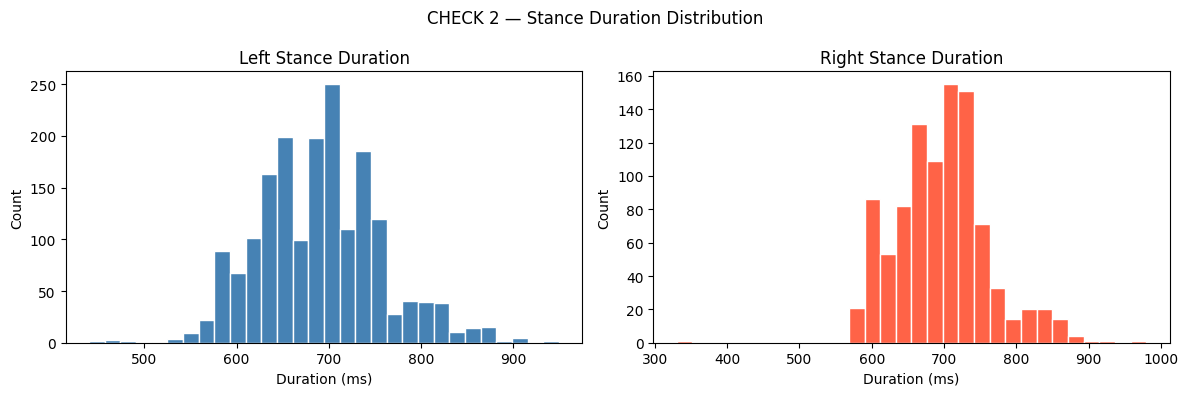

Left  — mean: 689ms  min: 440ms  max: 950ms
Right — mean: 695ms  min: 330ms  max: 980ms


In [49]:
# CHECK 2 — duration distribution
import matplotlib.pyplot as plt

durations_left  = [seg['duration'] * 10 for seg in all_segments if seg['side'] == 'left']
durations_right = [seg['duration'] * 10 for seg in all_segments if seg['side'] == 'right']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(durations_left, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Left Stance Duration')
axes[0].set_xlabel('Duration (ms)')
axes[0].set_ylabel('Count')

axes[1].hist(durations_right, bins=30, color='tomato', edgecolor='white')
axes[1].set_title('Right Stance Duration')
axes[1].set_xlabel('Duration (ms)')
axes[1].set_ylabel('Count')

plt.suptitle('CHECK 2 — Stance Duration Distribution', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Left  — mean: {np.mean(durations_left):.0f}ms  min: {np.min(durations_left)}ms  max: {np.max(durations_left)}ms")
print(f"Right — mean: {np.mean(durations_right):.0f}ms  min: {np.min(durations_right)}ms  max: {np.max(durations_right)}ms")

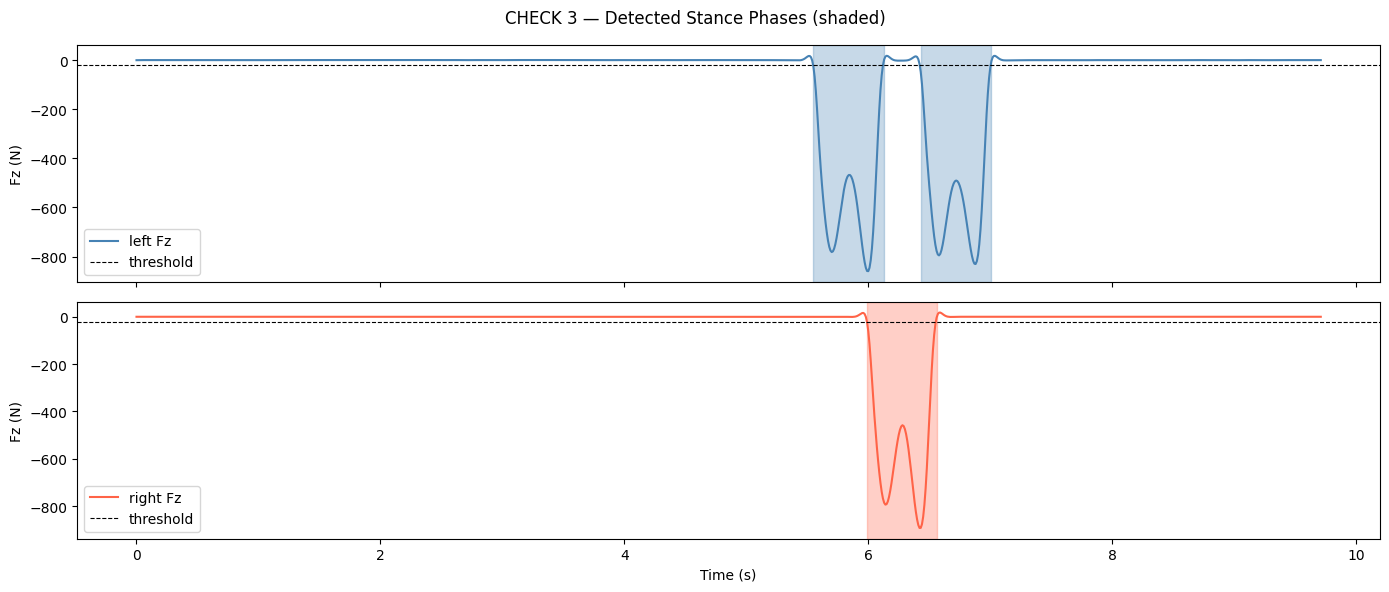

In [50]:
# CHECK 3 — visualize segmented phases on GRF signal
grf = all_grf_filtered[0]
time = np.arange(len(grf)) / 100

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ax, side, color in zip(axes, ['left', 'right'], ['steelblue', 'tomato']):
    fz = grf[f'{side}_Fz'].values
    ax.plot(time, fz, color=color, lw=1.5, label=f'{side} Fz')

    # shade detected stance phases
    trial_segs = [s for s in all_segments if s['trial_idx'] == 0 and s['side'] == side]
    for seg in trial_segs:
        ax.axvspan(seg['start'] / 100, seg['end'] / 100, alpha=0.3, color=color)

    ax.axhline(-20, color='black', lw=0.8, linestyle='--', label='threshold')
    ax.set_ylabel('Fz (N)')
    ax.legend()

axes[1].set_xlabel('Time (s)')
plt.suptitle('CHECK 3 — Detected Stance Phases (shaded)', fontsize=12)
plt.tight_layout()
plt.show()

In [51]:
# save segmented data
import joblib

backup_segmented = {
    'all_imu_filtered': all_imu_filtered,
    'all_grf_filtered': all_grf_filtered,
    'all_segments': all_segments,
    'trial_labels': trial_labels,
}

save_path = "/content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/segmented_2786phases.joblib"
joblib.dump(backup_segmented, save_path)
print(f"saved to: {save_path}")
print(f"file size: {os.path.getsize(save_path) / 1e6:.1f} MB")

saved to: /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/segmented_2786phases.joblib
file size: 142.5 MB


**Intepretation**
- Individual stance phases were detected from the filtered GRF signals using a vertical force threshold of -20 N.
- A stance phase begins when Fz drops below the threshold (heel strike) and ends when it returns above it (toe-off). Segments shorter than 300ms were rejected as noise.
- Each trial yields approximately 3 stance phases — 2 from the left foot (plates 1 and 3) and 1 from the right foot (plate 2), consistent with the 3-plate walking setup.
- Breakdown
1. trials with 1 phase:  0
2. trials with 2 phases: 4
3. trials with 3 phases: 926
4. trials with 4 phases: 0
5. trials with 5+phases: 0

- The 4 trials with 2 phases reflect weak plate contact, not a pipeline error

- A total of 2786 stance phases were detected across 930 trials: 1818 left and 968 right, averaging ~3 phases per trial.

- The average stance duration was 691ms, typical for comfortable walking. These are stance phases, not full gait cycles — swing phases are not captured by the force plates.

**Checks done**
- Check 1 — Phases Per Trial
1. 926 out of 930 trials (99.6%) had exactly 3 stance phases as expected. The 4 remaining trials (participant 22: r_comf_02, r_comf_06; participant 37: l_comf_01, l_comf_02) had only 2 phases.

2. This is consistent with the dataset paper's noted limitation that some participants failed to step cleanly on a plate — the contact force did not cross the -20 N threshold and was therefore not detected. This is not a pipeline error.

- Check 2 — Stance Duration Distribution
1. Left and right stance durations were both bell-shaped and centered around 690–700ms, with no implausible values. Left ranged from 440–950ms, right from 330–980ms — both consistent with comfortable walking.

- Check 3 — Visual Inspection
1. Detected stance phases were overlaid as shaded regions on the filtered GRF signal for trial 0. The shaded regions correctly covered heel strike to toe-off for both feet, with no mislabeled or missed contacts.

## G. Time Normalization

In [52]:
# H. Time Normalization
from scipy.interpolate import interp1d

TARGET_LENGTH = 100  # normalize all stance phases to 100 points (0-100% stance)

imu_normalized = []
grf_normalized = []
segment_labels = []

for seg in all_segments:
    idx   = seg['trial_idx']
    s     = seg['start']
    e     = seg['end']
    side  = seg['side']

    # extract stance window
    imu_window = all_imu_filtered[idx].values[s:e]
    grf_window = all_grf_filtered[idx].values[s:e]

    # resample to TARGET_LENGTH
    original_points = np.linspace(0, 1, len(imu_window))
    target_points   = np.linspace(0, 1, TARGET_LENGTH)

    imu_resampled = np.array([
        interp1d(original_points, imu_window[:, ch])(target_points)
        for ch in range(imu_window.shape[1])
    ]).T

    grf_resampled = np.array([
        interp1d(original_points, grf_window[:, ch])(target_points)
        for ch in range(grf_window.shape[1])
    ]).T

    imu_normalized.append(imu_resampled)
    grf_normalized.append(grf_resampled)
    segment_labels.append((seg['pid'], seg['trial'], seg['side']))

print(f"normalized: {len(imu_normalized)} stance phases")
print(f"imu shape per phase: {imu_normalized[0].shape}")
print(f"grf shape per phase: {grf_normalized[0].shape}")

normalized: 2786 stance phases
imu shape per phase: (100, 18)
grf shape per phase: (100, 6)


**Time Normalization Checks**

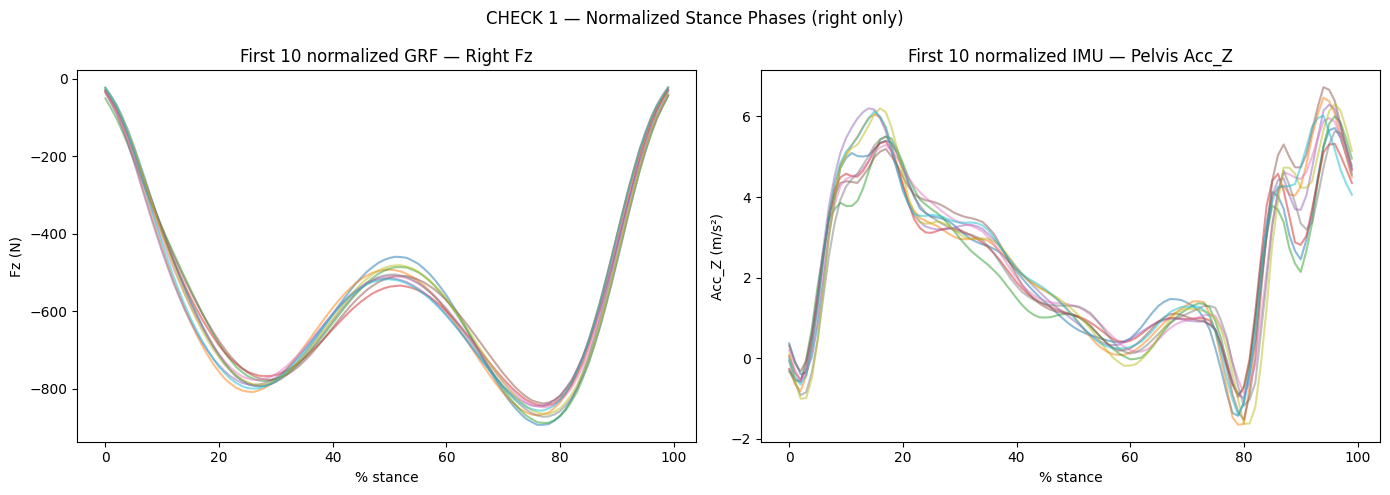

In [54]:
# CHECK 1 — show only right stance phases
right_indices = [i for i, seg in enumerate(all_segments) if seg['side'] == 'right']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in right_indices[:10]:
    axes[0].plot(grf_normalized[i][:, 5], alpha=0.5)
axes[0].set_title('First 10 normalized GRF — Right Fz')
axes[0].set_xlabel('% stance')
axes[0].set_ylabel('Fz (N)')

for i in right_indices[:10]:
    axes[1].plot(imu_normalized[i][:, 2], alpha=0.5)
axes[1].set_title('First 10 normalized IMU — Pelvis Acc_Z')
axes[1].set_xlabel('% stance')
axes[1].set_ylabel('Acc_Z (m/s²)')

plt.suptitle('CHECK 1 — Normalized Stance Phases (right only)', fontsize=12)
plt.tight_layout()
plt.show()

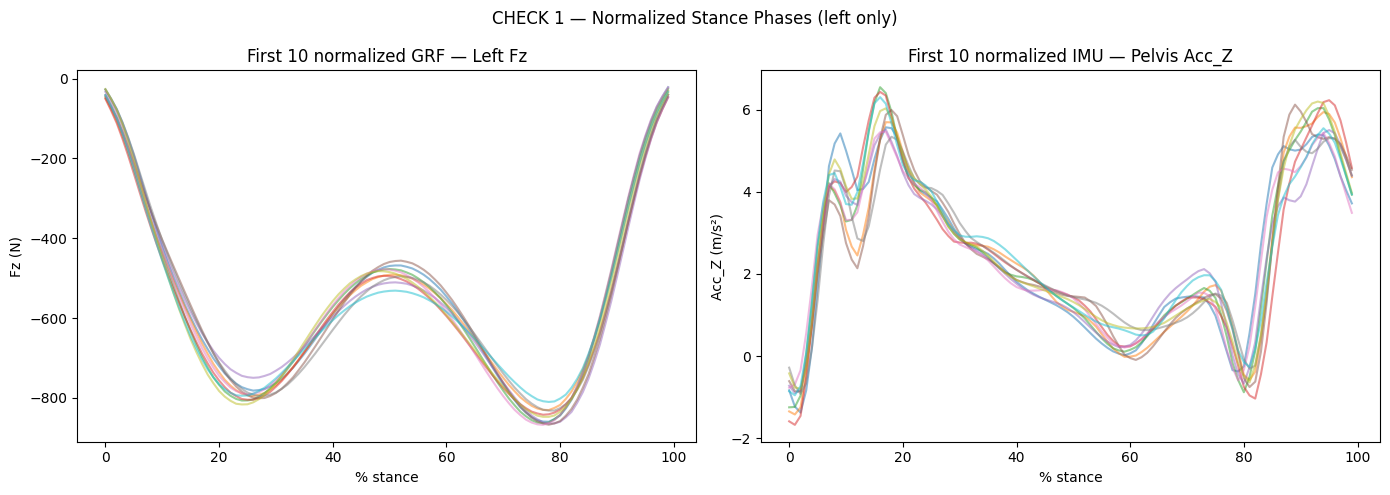

In [55]:
# left stance phases
left_indices = [i for i, seg in enumerate(all_segments) if seg['side'] == 'left']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in left_indices[:10]:
    axes[0].plot(grf_normalized[i][:, 2], alpha=0.5)  # left Fz
axes[0].set_title('First 10 normalized GRF — Left Fz')
axes[0].set_xlabel('% stance')
axes[0].set_ylabel('Fz (N)')

for i in left_indices[:10]:
    axes[1].plot(imu_normalized[i][:, 2], alpha=0.5)
axes[1].set_title('First 10 normalized IMU — Pelvis Acc_Z')
axes[1].set_xlabel('% stance')
axes[1].set_ylabel('Acc_Z (m/s²)')

plt.suptitle('CHECK 1 — Normalized Stance Phases (left only)', fontsize=12)
plt.tight_layout()
plt.show()

In [56]:
# CHECK 2 — shape consistency
shapes_ok = all(arr.shape == (100, 18) for arr in imu_normalized)
shapes_ok_grf = all(arr.shape == (100, 6) for arr in grf_normalized)

print(f"all IMU phases shape (100, 18): {shapes_ok}")
print(f"all GRF phases shape (100, 6):  {shapes_ok_grf}")

# check for NaNs
nan_count = sum(1 for arr in imu_normalized if np.isnan(arr).any())
nan_count_grf = sum(1 for arr in grf_normalized if np.isnan(arr).any())

print(f"IMU phases with NaNs: {nan_count}")
print(f"GRF phases with NaNs: {nan_count_grf}")

all IMU phases shape (100, 18): True
all GRF phases shape (100, 6):  True
IMU phases with NaNs: 0
GRF phases with NaNs: 0


In [57]:
backup_normalized = {
    'imu_normalized': imu_normalized,
    'grf_normalized': grf_normalized,
    'segment_labels': segment_labels,
    'all_segments': all_segments,
}

save_path = "/content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/normalized_2786phases.joblib"
joblib.dump(backup_normalized, save_path)
print(f"saved to: {save_path}")

saved to: /content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/normalized_2786phases.joblib


**Intepretation**
- Stance phases across 2786 segments varied in duration (330ms–980ms), making them incompatible as direct model inputs.
- Each stance phase was resampled to a fixed length of 100 points using linear interpolation (scipy.interpolate.interp1d), representing 0%–100% of the stance phase regardless of actual duration.
- This ensures all input samples are the same size for model training

**Checks done**
- Check 1 — Visual Inspection
1. The first 10 normalized stance phases were plotted separately for left and right feet.
2. Both showed the expected GRF double-bump pattern — first peak at approximately 20% stance (heel strike loading), midstance dip at approximately 50%, second peak at approximately 80% (push-off) — with tight overlap across trials.
3. IMU Pelvis Acc_Z showed consistent patterns with natural between-participant variability. Normalization preserved signal shape correctly for both feet.

- Check 2 — Shape and NaN Consistency
1. All 2786 IMU phases confirmed shape (100, 18) and all GRF phases confirmed shape (100, 6). Zero NaNs were found across all phases in both IMU and GRF.

**Model Ready Datasets**

In [58]:
print(all_imu[0].columns.tolist())

['Pelvis_Acc_X', 'Pelvis_Acc_Y', 'Pelvis_Acc_Z', 'Pelvis_Gyr_X', 'Pelvis_Gyr_Y', 'Pelvis_Gyr_Z', 'left_tibia_Acc_X', 'left_tibia_Acc_Y', 'left_tibia_Acc_Z', 'left_tibia_Gyr_X', 'left_tibia_Gyr_Y', 'left_tibia_Gyr_Z', 'right_tibia_Acc_X', 'right_tibia_Acc_Y', 'right_tibia_Acc_Z', 'right_tibia_Gyr_X', 'right_tibia_Gyr_Y', 'right_tibia_Gyr_Z']


In [59]:
print(all_grf[0].columns.tolist())

['left_Fx', 'left_Fy', 'left_Fz', 'right_Fx', 'right_Fy', 'right_Fz']


In [60]:
import pandas as pd
import numpy as np

imu_cols = all_imu[0].columns.tolist()

# column indices per config
config1_imu = list(range(0, 6))    # pelvis only
config2_imu = list(range(6, 18))   # bilateral shanks
config3_imu = list(range(0, 18))   # all

rows_c1, rows_c2, rows_c3 = [], [], []

for i, (pid, trial, side) in enumerate(segment_labels):
    imu = imu_normalized[i]  # (100, 18)
    grf = grf_normalized[i]  # (100, 6)

    # GRF columns: left_Fx=0, left_Fy=1, left_Fz=2, right_Fx=3, right_Fy=4, right_Fz=5
    resultant_Fz = grf[:, 2] + grf[:, 5]  # left + right Fz

    base = {'pid': pid, 'trial': trial, 'side': side}

    # flatten time series into single row
    def flatten(arr, prefix):
        return {f"{prefix}_t{t}": arr[t] for t in range(100)}

    # Config 1 — pelvis + resultant
    row1 = {**base}
    for j, col_idx in enumerate(config1_imu):
        row1.update(flatten(imu[:, col_idx], imu_cols[col_idx]))
    row1.update(flatten(resultant_Fz, 'resultant_Fz'))
    rows_c1.append(row1)

    # Config 2 — shanks + bilateral GRF
    row2 = {**base}
    for j, col_idx in enumerate(config2_imu):
        row2.update(flatten(imu[:, col_idx], imu_cols[col_idx]))
    for col_name, col_idx in zip(['left_Fx','left_Fy','left_Fz','right_Fx','right_Fy','right_Fz'], range(6)):
        row2.update(flatten(grf[:, col_idx], col_name))
    rows_c2.append(row2)

    # Config 3 — all IMU + bilateral + resultant
    row3 = {**base}
    for j, col_idx in enumerate(config3_imu):
        row3.update(flatten(imu[:, col_idx], imu_cols[col_idx]))
    for col_name, col_idx in zip(['left_Fx','left_Fy','left_Fz','right_Fx','right_Fy','right_Fz'], range(6)):
        row3.update(flatten(grf[:, col_idx], col_name))
    row3.update(flatten(resultant_Fz, 'resultant_Fz'))
    rows_c3.append(row3)

df_c1 = pd.DataFrame(rows_c1)
df_c2 = pd.DataFrame(rows_c2)
df_c3 = pd.DataFrame(rows_c3)

print(f"Config 1 shape: {df_c1.shape}")
print(f"Config 2 shape: {df_c2.shape}")
print(f"Config 3 shape: {df_c3.shape}")

Config 1 shape: (2786, 703)
Config 2 shape: (2786, 1803)
Config 3 shape: (2786, 2503)


In [61]:
save_dir = "/content/drive/MyDrive/GRF_Project/Data-Lavikinean-51/"

df_c1.to_csv(save_dir + "config1_pelvis.csv", index=False)
df_c2.to_csv(save_dir + "config2_shanks.csv", index=False)
df_c3.to_csv(save_dir + "config3_fusion.csv", index=False)

print("saved:")
print(f"  config1_pelvis.csv  — {df_c1.shape}")
print(f"  config2_shanks.csv  — {df_c2.shape}")
print(f"  config3_fusion.csv  — {df_c3.shape}")

saved:
  config1_pelvis.csv  — (2786, 703)
  config2_shanks.csv  — (2786, 1803)
  config3_fusion.csv  — (2786, 2503)


**Intepretation**
- The 2786 normalized stance phases were packaged into 3 CSV datasets corresponding to the planned sensor configurations.
- Each row represents one stance phase — 100 time-normalized samples per channel flattened into a single row, with pid, trial, and side as metadata columns.

**Configurations**
- Config 1 — Pelvis only (config1_pelvis.csv)
IMU input: 6 Pelvis channels × 100 points = 600 columns. GRF target: resultant Fz (left + right summed) × 100 points = 100 columns. Total: 2786 × 703.

- Config 2 — Bilateral shanks (config2_shanks.csv)
IMU input: 12 shank channels × 100 points = 1200 columns. GRF target: bilateral GRF (left + right, all 3 components) × 100 points = 600 columns. Total: 2786 × 1803.

- Config 3 — Full fusion (config3_fusion.csv)
IMU input: 18 channels × 100 points = 1800 columns. GRF target: bilateral GRF + resultant Fz × 100 points = 700 columns. Total: 2786 × 2503.